In [1]:
import pandas as pd
import numpy as np

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
data = pd.read_csv("merged.csv")

In [3]:
data.head()

,credit_score,oldest_credit_line_age,oldest_account_age_months,num_credit_accounts,num_inquiries_6mo,account_diversity_index,total_delinquencies,credit_utilization_ratio,recent_inquiry_ratio,id,...,num_login_sessions,num_customer_service_calls,account_status_code,paperless_billing,has_mobile_app,account_open_year,preferred_contact,application_hour,application_day_of_week,default
0,696,22.0,264.0,14,2,0.499,1.0,12078.571429,0.142857,10000,...,13,2,2,1,1,2013,1,5,6,0
1,659,3.5,42.0,13,5,0.298,0.0,6015.384615,0.384615,10001,...,6,1,3,1,1,2015,2,4,2,1
2,662,0.0,0.0,3,2,0.174,0.0,13800.000000,0.666667,10002,...,2,2,3,0,1,2020,2,10,3,0
3,676,9.0,108.0,8,1,0.263,0.0,7500.000000,0.125000,10003,...,4,1,0,1,1,2010,0,7,5,0
4,678,8.0,96.0,7,1,0.298,0.0,7100.000000,0.142857,10004,...,6,2,3,0,1,2020,1,1,2,0


In [4]:
data.shape

(89999, 60)

In [6]:
# CSV ni o'qish
data = pd.read_csv("merged.csv")

# Target va feature ajratish
X = data.drop(columns=['id', 'default'])  # id ni modelga kiritmaymiz
y = data['default']

# Training va test uchun bo'lish
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


ValueError: could not convert string to float: 'CA'

In [8]:
categorical_cols = X.select_dtypes(include=['object']).columns
print(categorical_cols)


Index(['state'], dtype='object')


In [9]:
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [11]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [12]:
y_pred = model.predict(X_test_scaled)

# Natijalarni baholash
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.9478333333333333
Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97     17062
           1       0.49      0.03      0.05       938

    accuracy                           0.95     18000
   macro avg       0.72      0.51      0.51     18000
weighted avg       0.93      0.95      0.93     18000

Confusion Matrix:
 [[17034    28]
 [  911    27]]


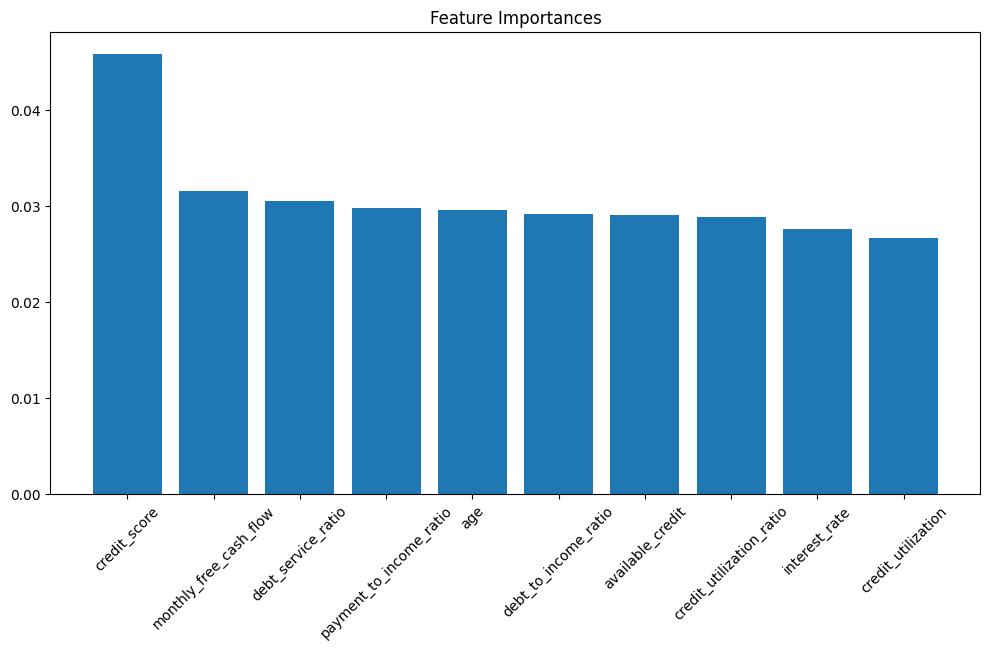

In [13]:
import matplotlib.pyplot as plt
import numpy as np

importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12,6))
plt.title("Feature Importances")
plt.bar(range(10), importances[indices][:10], align="center")
plt.xticks(range(10), X.columns[indices][:10], rotation=45)
plt.show()


Categorical columns: Index(['state'], dtype='object')
[LightGBM] [Info] Number of positive: 3656, number of negative: 68343
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.021070 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6801
[LightGBM] [Info] Number of data points in the train set: 71999, number of used features: 76
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050778 -> initscore=-2.928169
[LightGBM] [Info] Start training from score -2.928169
LightGBM AUC: 0.7916251566155691


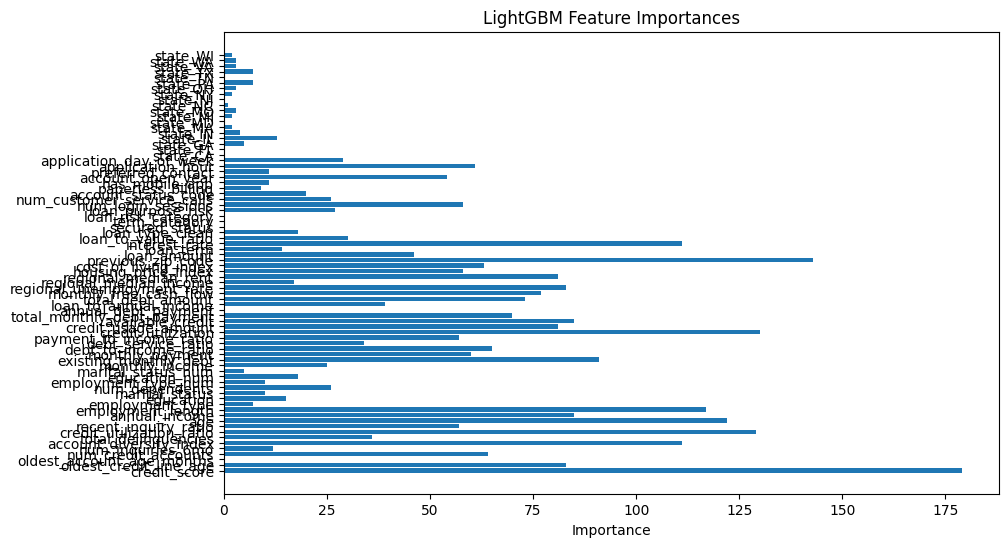

c:\Users\behru\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [01:33:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost AUC: 0.7648624519780987
CatBoost AUC: 0.7933337440599805
Eng yaxshi model: CatBoost with AUC = 0.7933337440599805


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# CSV faylni o'qish
data = pd.read_csv("merged.csv")

# Target va feature ajratish
y = data["default"]
X = data.drop(columns=['id','default'])  # id modelga kirmasligi kerak

# Categorical columnlarni aniqlash
categorical_cols = X.select_dtypes(include=['object']).columns
print("Categorical columns:", categorical_cols)

# One-hot encode categorical columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Train-test split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modellar va metrics
from sklearn.metrics import roc_auc_score
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier

# ------------------ LightGBM ------------------
lgb_model = lgb.LGBMClassifier(random_state=42)
lgb_model.fit(x_train, y_train)
lgb_pred = lgb_model.predict_proba(x_test)[:,1]
lgb_auc = roc_auc_score(y_test, lgb_pred)
print("LightGBM AUC:", lgb_auc)

# Feature importance
plt.figure(figsize=(10,6))
plt.barh(x_train.columns, lgb_model.feature_importances_)
plt.xlabel("Importance")
plt.title("LightGBM Feature Importances")
plt.show()

# ------------------ XGBoost ------------------
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(x_train, y_train)
xgb_pred = xgb_model.predict_proba(x_test)[:,1]
xgb_auc = roc_auc_score(y_test, xgb_pred)
print("XGBoost AUC:", xgb_auc)

# ------------------ CatBoost ------------------
cat_model = CatBoostClassifier(verbose=0, random_state=42)
cat_model.fit(x_train, y_train)
cat_pred = cat_model.predict_proba(x_test)[:,1]
cat_auc = roc_auc_score(y_test, cat_pred)
print("CatBoost AUC:", cat_auc)

# ------------------ AUC solishtirish ------------------
auc_scores = {"LightGBM": lgb_auc, "XGBoost": xgb_auc, "CatBoost": cat_auc}
best_model_name = max(auc_scores, key=auc_scores.get)
print("Eng yaxshi model:", best_model_name, "with AUC =", auc_scores[best_model_name])


                       feature  importance
0                 credit_score    9.007035
9                          age    5.236399
41               interest_rate    3.391336
32      monthly_free_cash_flow    3.288251
38           previous_zip_code    3.020734
27            available_credit    3.012034
25          credit_utilization    2.987164
7     credit_utilization_ratio    2.955638
20       existing_monthly_debt    2.819176
24     payment_to_income_ratio    2.800873
5      account_diversity_index    2.708241
35        regional_median_rent    2.648556
33  regional_unemployment_rate    2.602754
19              monthly_income    2.601521
10               annual_income    2.545119
22        debt_to_income_ratio    2.425596
55            application_hour    2.360070
37        cost_of_living_index    2.313325
30       loan_to_annual_income    2.211023
23          debt_service_ratio    2.145842


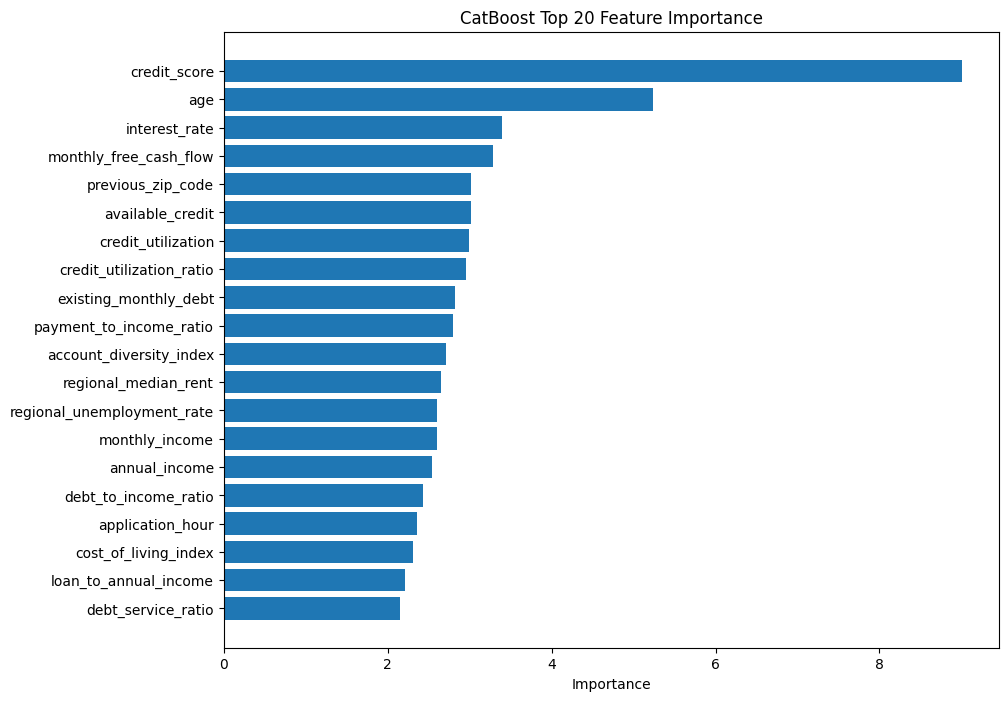

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# CatBoost model allaqachon fit qilingan deb faraz qilamiz: cat_model

# Feature importances olish
importances = cat_model.get_feature_importance()
features = x_train.columns

# DataFrame yaratish
feat_imp = pd.DataFrame({"feature": features, "importance": importances})
feat_imp = feat_imp.sort_values(by="importance", ascending=False)

# Top 20 feature ni ko'rsatish
print(feat_imp.head(20))

# Vizual
plt.figure(figsize=(10,8))
plt.barh(feat_imp['feature'][:20], feat_imp['importance'][:20])
plt.xlabel("Importance")
plt.title("CatBoost Top 20 Feature Importance")
plt.gca().invert_yaxis()
plt.show()


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from catboost import CatBoostClassifier

# Misol: top 30 eng muhim feature ni ishlatamiz
top_features = feat_imp['feature'][:30].tolist()

X_top = X[top_features]

x_train2, x_test2, y_train2, y_test2 = train_test_split(X_top, y, test_size=0.2, random_state=42)

# Modelni qayta fit qilish
cat_model2 = CatBoostClassifier(verbose=0, random_state=42)
cat_model2.fit(x_train2, y_train2)
cat_pred2 = cat_model2.predict_proba(x_test2)[:,1]
cat_auc2 = roc_auc_score(y_test2, cat_pred2)

print("CatBoost AUC (top 30 features):", cat_auc2)


CatBoost AUC (top 30 features): 0.790676246844882


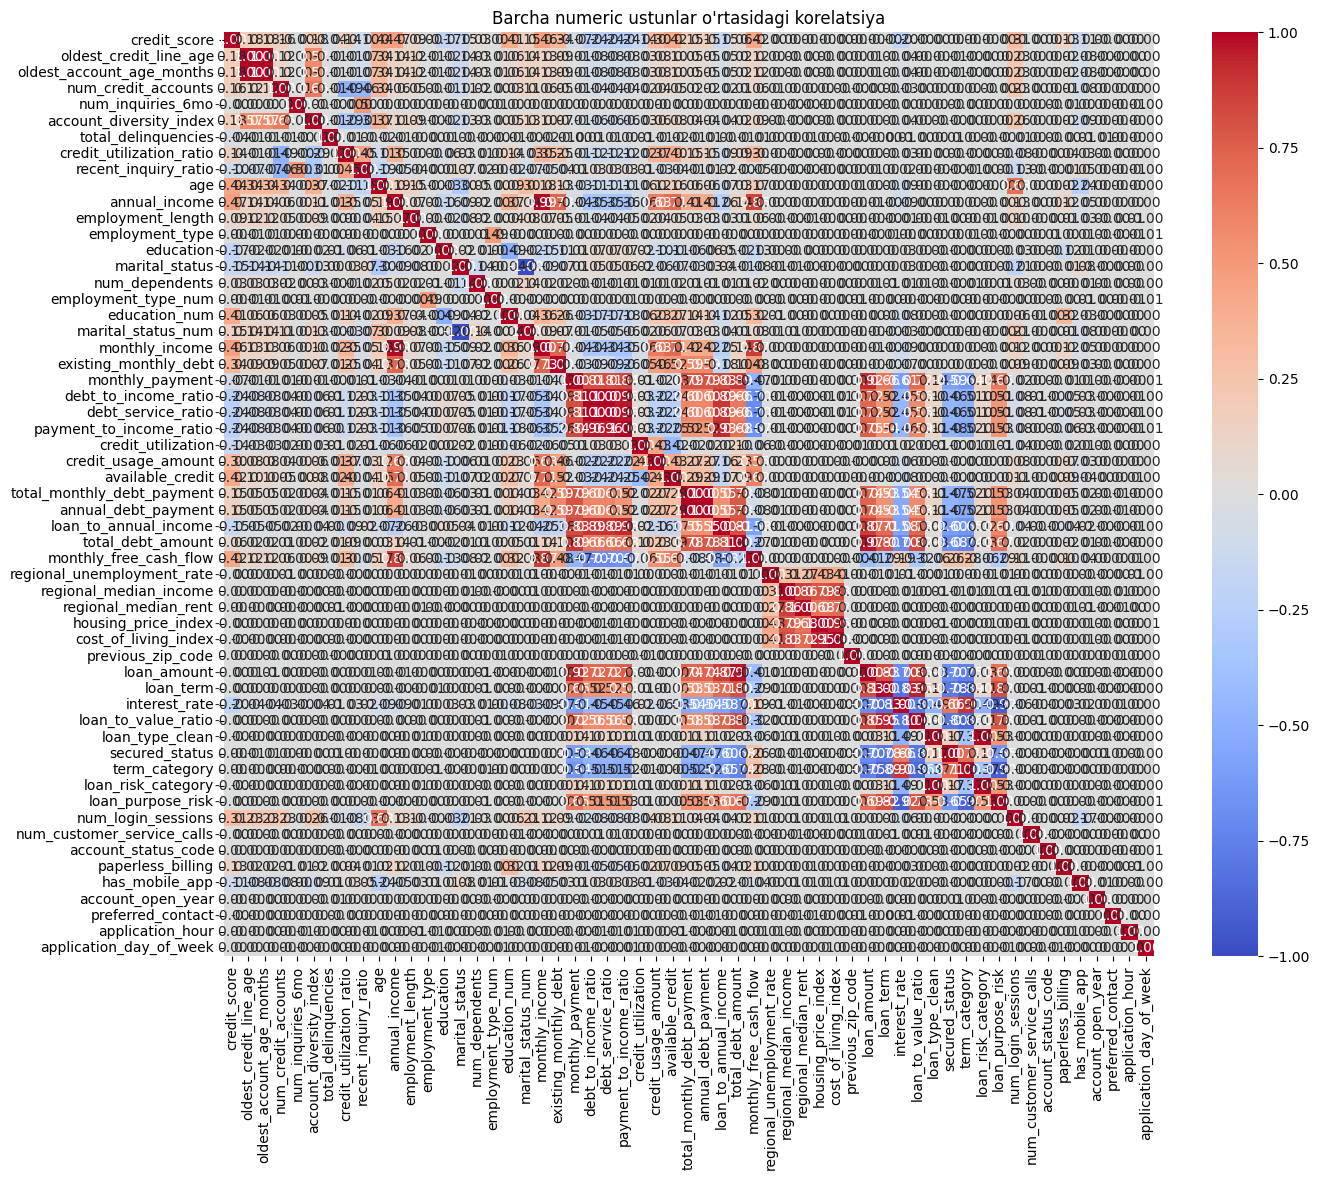

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# numeric ustunlarni ajratish
numeric_cols = X.select_dtypes(include=np.number).columns
matrix = X[numeric_cols].corr()

# Vizualizatsiya
plt.figure(figsize=(15,12))
sns.heatmap(matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Barcha numeric ustunlar o'rtasidagi korelatsiya")
plt.show()


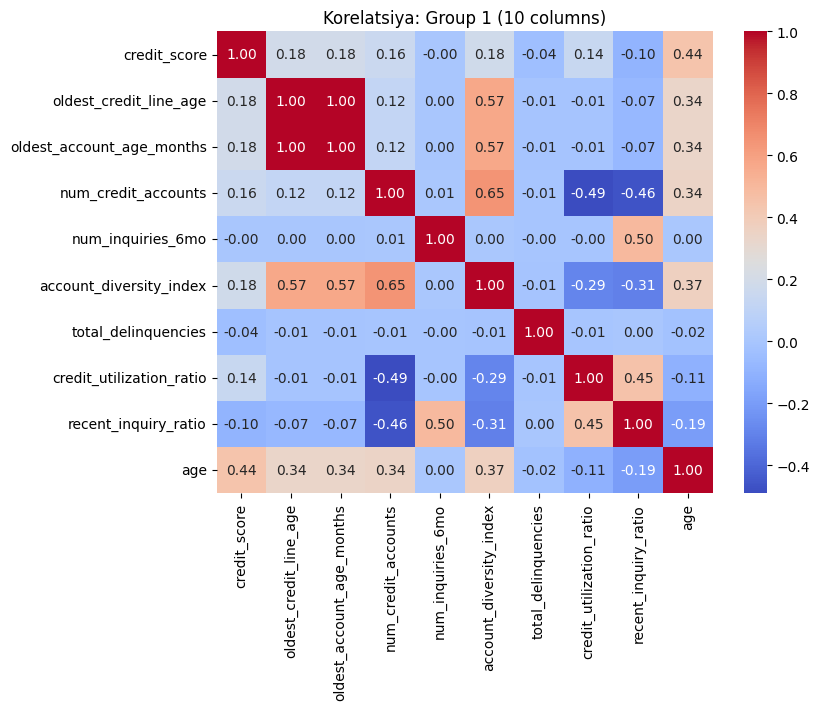

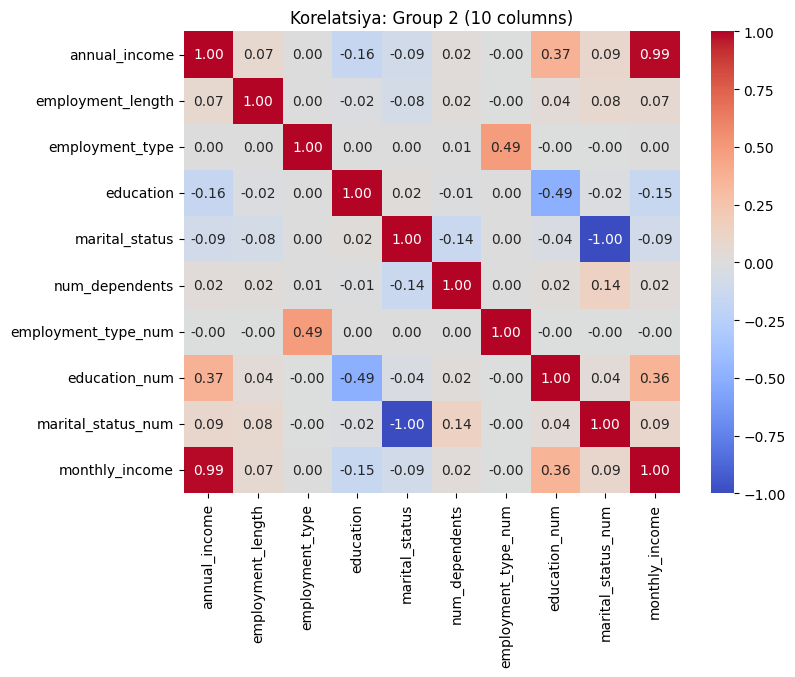

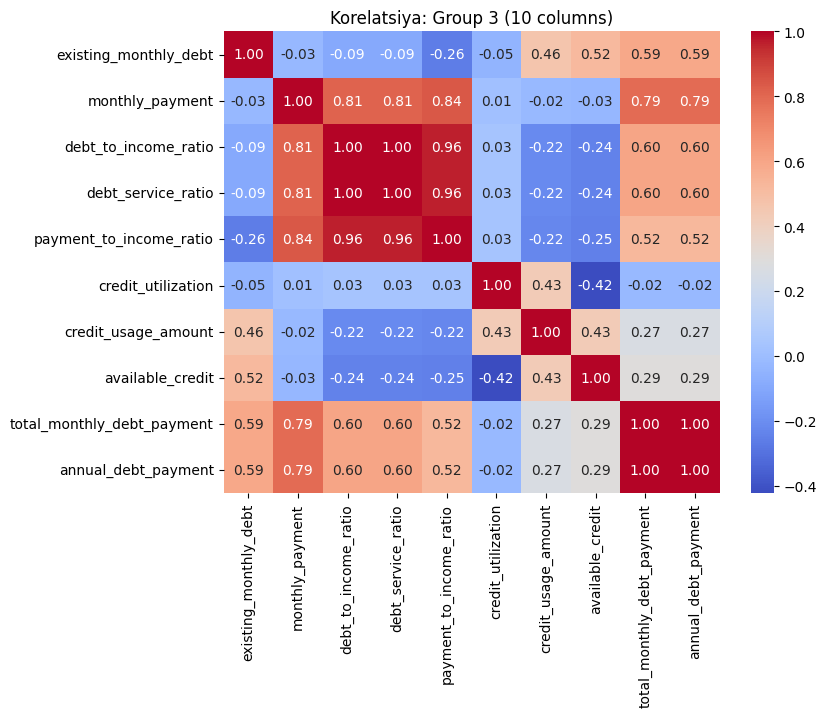

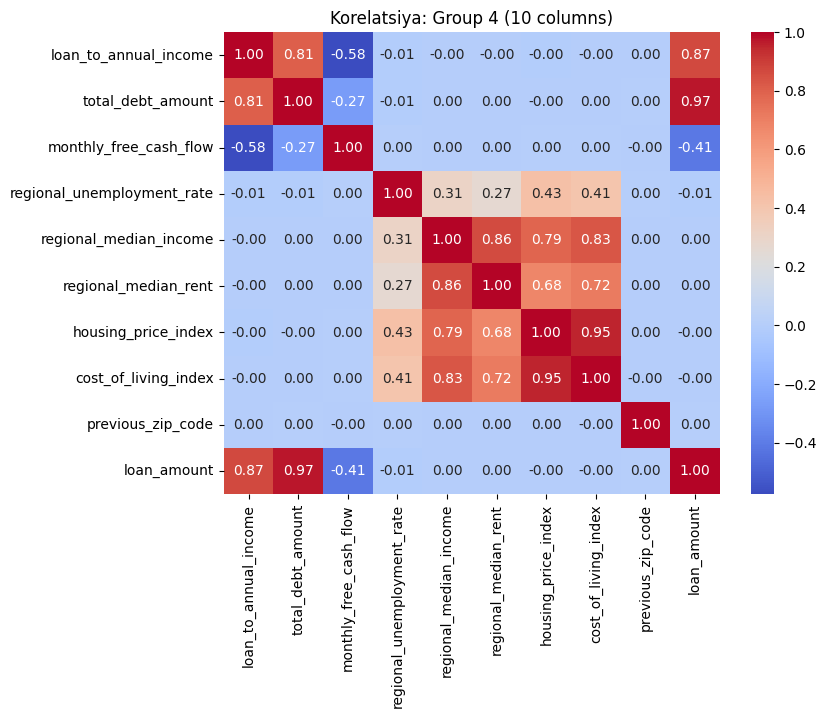

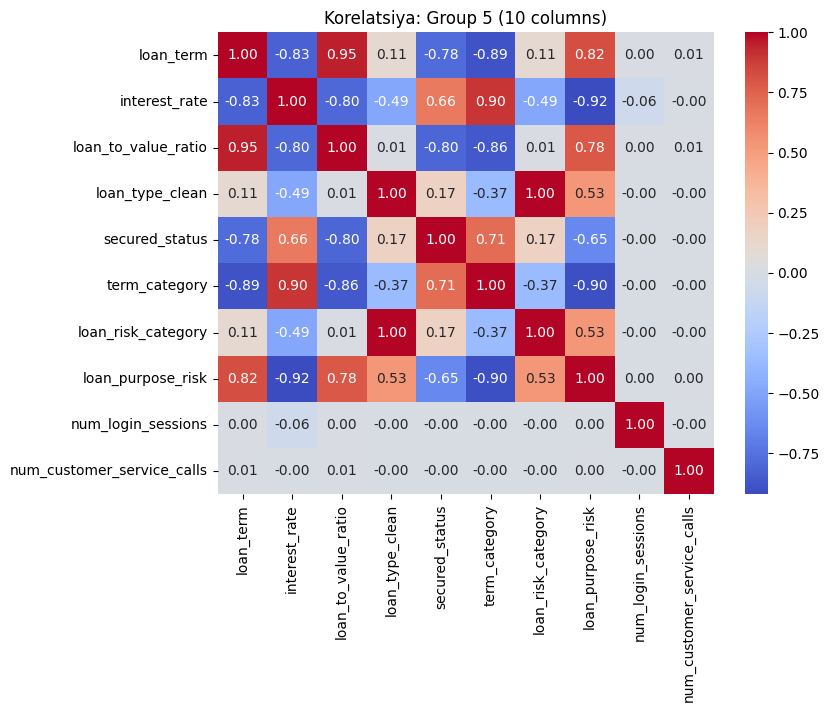

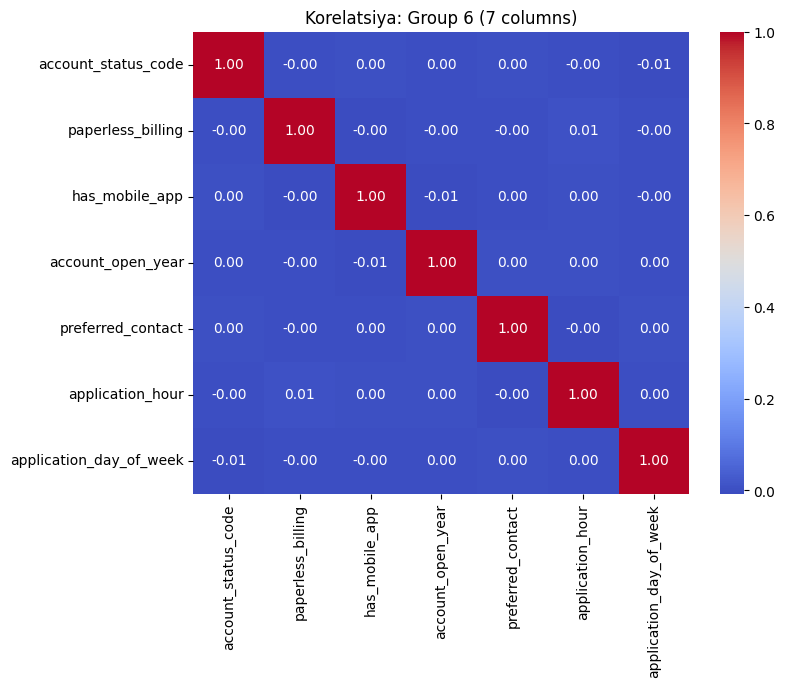

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Numeric ustunlarni ajratish
numeric_cols = X.select_dtypes(include=np.number).columns
total_cols = len(numeric_cols)

# 10 ta 10 ta guruhlash
group_size = 10
num_groups = int(np.ceil(total_cols / group_size))

for i in range(num_groups):
    start = i * group_size
    end = min((i+1) * group_size, total_cols)
    cols_group = numeric_cols[start:end]
    
    # Korelatsiya matritsasi
    corr_matrix = X[cols_group].corr()
    
    # Heatmap
    plt.figure(figsize=(8,6))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
    plt.title(f"Korelatsiya: Group {i+1} ({len(cols_group)} columns)")
    plt.show()


In [19]:
import pandas as pd
import numpy as np

# Numeric ustunlarni ajratish
numeric_cols = X.select_dtypes(include=np.number).columns
total_cols = len(numeric_cols)

# 10 ta 10 ta guruhlash
group_size = 10
num_groups = int(np.ceil(total_cols / group_size))

for i in range(num_groups):
    start = i * group_size
    end = min((i+1) * group_size, total_cols)
    cols_group = numeric_cols[start:end]
    
    # Korelatsiya matritsasi
    corr_matrix = X[cols_group].corr()
    
    print(f"\nKorelatsiya: Group {i+1} ({len(cols_group)} columns)")
    print(corr_matrix)



Korelatsiya: Group 1 (10 columns)
                           credit_score  oldest_credit_line_age  \
credit_score                   1.000000                0.184977   
oldest_credit_line_age         0.184977                1.000000   
oldest_account_age_months      0.184977                1.000000   
num_credit_accounts            0.155123                0.115746   
num_inquiries_6mo             -0.000733                0.002845   
account_diversity_index        0.183210                0.573298   
total_delinquencies           -0.040099               -0.012151   
credit_utilization_ratio       0.138426               -0.007856   
recent_inquiry_ratio          -0.097557               -0.074790   
age                            0.443576                0.335378   

                           oldest_account_age_months  num_credit_accounts  \
credit_score                                0.184977             0.155123   
oldest_credit_line_age                      1.000000             0.115746

In [20]:
selected_features = [
    # Group 1
    "credit_score", "age", "account_diversity_index",
    # Group 2
    "annual_income", "education_num",
    # Group 3
    "debt_to_income_ratio",
    # Group 4
    "loan_amount",
    # Group 5
    "loan_to_value_ratio",
    # Group 6
    "account_status_code", "paperless_billing", "has_mobile_app",
    "account_open_year", "preferred_contact", "application_hour",
    "application_day_of_week"
]


In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from catboost import CatBoostClassifier

# Data va target
X = data[selected_features]
y = data["default"]

# Train-test split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# CatBoost modeli
cat_model = CatBoostClassifier(verbose=0, random_state=42)
cat_model.fit(x_train, y_train)

# Bashorat va AUC
cat_pred = cat_model.predict_proba(x_test)[:,1]
cat_auc = roc_auc_score(y_test, cat_pred)

print("CatBoost AUC (selected features):", cat_auc)

# Feature importance (top 10)
feat_imp = pd.DataFrame({
    "feature": selected_features,
    "importance": cat_model.get_feature_importance()
}).sort_values(by="importance", ascending=False)

print("\nTop feature importances:")
print(feat_imp.head(10))


CatBoost AUC (selected features): 0.7885655450996605

Top feature importances:
                    feature  importance
0              credit_score   16.769829
5      debt_to_income_ratio   13.274023
3             annual_income   11.069061
1                       age   10.592480
6               loan_amount   10.167209
2   account_diversity_index    9.188354
13         application_hour    6.692846
11        account_open_year    5.491562
7       loan_to_value_ratio    4.488648
14  application_day_of_week    3.754074


In [25]:
import pandas as pd
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# Ma'lumotlarni yuklash (misol uchun CSV)
data = pd.read_csv("merged.csv")

# Tanlangan ustunlar
selected_features = [
    'credit_score',
    'debt_to_income_ratio',
    'annual_income',
    'age',
    'loan_amount',          # yoki 'loan_to_annual_income'
    'account_diversity_index',
    'application_hour',
    'account_open_year',
    'loan_to_value_ratio',
    'application_day_of_week'
]

# Maqsadli ustun
target = 'default'  # sizning target ustuningiz nomi

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    data[selected_features], data[target], test_size=0.2, random_state=42
)

# CatBoost Classifier yaratish
model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    eval_metric='AUC',
    random_seed=42,
    verbose=100
)

# Modelni o'qitish
model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    use_best_model=True
)

# Prognoz va AUC baholash
y_pred = model.predict_proba(X_test)[:, 1]
auc_score = roc_auc_score(y_test, y_pred)
print(f"CatBoost AUC (selected features): {auc_score}")


0:	test: 0.7298829	best: 0.7298829 (0)	total: 22.3ms	remaining: 22.3s
100:	test: 0.7966771	best: 0.7967024 (99)	total: 1.61s	remaining: 14.3s
200:	test: 0.7966887	best: 0.7969742 (182)	total: 3.31s	remaining: 13.1s
300:	test: 0.7968225	best: 0.7970479 (267)	total: 4.78s	remaining: 11.1s
400:	test: 0.7966845	best: 0.7971504 (338)	total: 6.27s	remaining: 9.37s
500:	test: 0.7964682	best: 0.7971504 (338)	total: 7.61s	remaining: 7.58s
600:	test: 0.7955747	best: 0.7971504 (338)	total: 8.74s	remaining: 5.8s
700:	test: 0.7945122	best: 0.7971504 (338)	total: 9.91s	remaining: 4.23s
800:	test: 0.7930544	best: 0.7971504 (338)	total: 11.1s	remaining: 2.75s
900:	test: 0.7918989	best: 0.7971504 (338)	total: 12.2s	remaining: 1.34s
999:	test: 0.7910806	best: 0.7971504 (338)	total: 13.4s	remaining: 0us

bestTest = 0.7971504402
bestIteration = 338

Shrink model to first 339 iterations.
CatBoost AUC (selected features): 0.797150440173165


In [26]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb

# Sizning selected features
selected_features = [
    'credit_score',
    'debt_to_income_ratio',
    'annual_income',
    'age',
    'loan_amount',  # yoki 'loan_to_annual_income'
    'account_diversity_index',
    'application_hour',
    'account_open_year',
    'loan_to_value_ratio',
    'application_day_of_week'
]

# Target ustun nomi (dataset’dagi haqiqiy nomini yozing)
target = 'default'  # misol uchun, o‘zingizni target ustuningizni qo‘ying

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    data[selected_features], data[target], test_size=0.2, random_state=42
)

# Model va natijalarni saqlash uchun lug‘at
models = {}
results = {}

# 1. CatBoost
cat_model = CatBoostClassifier(
    iterations=500, learning_rate=0.1, depth=6, verbose=0
)
cat_model.fit(X_train, y_train)
y_pred = cat_model.predict_proba(X_test)[:,1]
results['CatBoost'] = roc_auc_score(y_test, y_pred)
models['CatBoost'] = cat_model

# 2. Random Forest
rf_model = RandomForestClassifier(n_estimators=500, max_depth=8, random_state=42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict_proba(X_test)[:,1]
results['RandomForest'] = roc_auc_score(y_test, y_pred)
models['RandomForest'] = rf_model

# 3. XGBoost
xgb_model = XGBClassifier(n_estimators=500, max_depth=6, learning_rate=0.1, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict_proba(X_test)[:,1]
results['XGBoost'] = roc_auc_score(y_test, y_pred)
models['XGBoost'] = xgb_model

# 4. Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
y_pred = lr_model.predict_proba(X_test)[:,1]
results['LogisticRegression'] = roc_auc_score(y_test, y_pred)
models['LogisticRegression'] = lr_model

# 5. LightGBM
lgb_model = lgb.LGBMClassifier(n_estimators=500, learning_rate=0.1, max_depth=6)
lgb_model.fit(X_train, y_train)
y_pred = lgb_model.predict_proba(X_test)[:,1]
results['LightGBM'] = roc_auc_score(y_test, y_pred)
models['LightGBM'] = lgb_model

# Natijalarni chiqarish
print("Model AUC natijalari:")
for model_name, auc in results.items():
    print(f"{model_name}: {auc:.4f}")


c:\Users\behru\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [01:49:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 3656, number of negative: 68343
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001842 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1589
[LightGBM] [Info] Number of data points in the train set: 71999, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050778 -> initscore=-2.928169
[LightGBM] [Info] Start training from score -2.928169
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain